In [ ]:
#Libraray Import
import numpy as np
import pandas as pd
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneOut, train_test_split, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,auc
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from collections import Counter
import time

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving medical_data_clean.csv to medical_data_clean.csv


In [ ]:
# Assuming 'medical_data_clean.csv' was the uploaded file
df = pd.read_csv('medical_data_clean.csv')
display(df.head())

,S1_T1,S2_T1,S3_T1,S4_T1,S5_T1,S6_T1,S1_T2,S2_T2,S3_T2,S4_T2,...,S5_T3,S6_T3,Age,Sex,Smoking,LC_stage,LC_type,Group,Group_name,lscm
0,3.180000e-07,3.730000e-07,0.000230,9.420000e-07,5.440000e-07,7.010000e-07,6.790000e-07,6.920000e-07,0.000202,0.000004,...,8.850000e-07,7.660000e-07,50,1,1,3,0,1,LC group,4
1,3.300000e-07,2.770000e-07,0.000268,1.120000e-06,8.950000e-07,1.050000e-06,2.660000e-07,1.890000e-07,0.000095,0.000002,...,1.160000e-06,9.310000e-07,68,0,0,4,1,1,LC group,3
2,5.450000e-07,4.810000e-07,0.000527,2.400000e-06,2.260000e-06,2.310000e-06,7.360000e-07,5.290000e-07,0.000266,0.000005,...,4.080000e-06,3.070000e-06,70,1,1,1,1,1,LC group,4
3,3.780000e-07,4.190000e-07,0.000241,1.100000e-06,9.490000e-07,1.010000e-06,3.580000e-07,3.750000e-07,0.000095,0.000002,...,1.420000e-06,1.070000e-06,66,0,0,4,1,1,LC group,3
4,4.260000e-07,4.780000e-07,0.000276,1.440000e-06,8.630000e-07,1.050000e-06,4.350000e-07,4.680000e-07,0.000120,0.000003,...,1.400000e-06,1.190000e-06,69,1,1,1,1,1,LC group,4


In [ ]:
#Defining the X and Y variables
X = df.drop(columns=["Group","LC_stage","LC_type","lscm","Age","Sex","Smoking","Group_name"])
y = df["Group"]
display(X.head())
display(y.head())

,S1_T1,S2_T1,S3_T1,S4_T1,S5_T1,S6_T1,S1_T2,S2_T2,S3_T2,S4_T2,S5_T2,S6_T2,S1_T3,S2_T3,S3_T3,S4_T3,S5_T3,S6_T3
0,3.180000e-07,3.730000e-07,0.000230,9.420000e-07,5.440000e-07,7.010000e-07,6.790000e-07,6.920000e-07,0.000202,0.000004,0.000002,1.500000e-06,5.560000e-07,2.720000e-07,0.000035,0.000004,8.850000e-07,7.660000e-07
1,3.300000e-07,2.770000e-07,0.000268,1.120000e-06,8.950000e-07,1.050000e-06,2.660000e-07,1.890000e-07,0.000095,0.000002,0.000001,8.760000e-07,2.110000e-07,1.750000e-07,0.000035,0.000004,1.160000e-06,9.310000e-07
2,5.450000e-07,4.810000e-07,0.000527,2.400000e-06,2.260000e-06,2.310000e-06,7.360000e-07,5.290000e-07,0.000266,0.000005,0.000003,2.750000e-06,6.980000e-07,5.250000e-07,0.000119,0.000013,4.080000e-06,3.070000e-06
3,3.780000e-07,4.190000e-07,0.000241,1.100000e-06,9.490000e-07,1.010000e-06,3.580000e-07,3.750000e-07,0.000095,0.000002,0.000001,9.480000e-07,2.760000e-07,3.300000e-07,0.000038,0.000005,1.420000e-06,1.070000e-06
4,4.260000e-07,4.780000e-07,0.000276,1.440000e-06,8.630000e-07,1.050000e-06,4.350000e-07,4.680000e-07,0.000120,0.000003,0.000001,1.170000e-06,3.210000e-07,3.700000e-07,0.000044,0.000006,1.400000e-06,1.190000e-06


,Group
0,1
1,1
2,1
3,1
4,1


XGBoost Model

In [ ]:
def nested_stratified_kfold_cv(X, y, n_outer_splits=5, n_inner_splits=3, random_state=42, use_smote=False):

    print("="*60)
    print(f"Nested CV: {n_outer_splits} outer folds x {n_inner_splits} inner folds")
    print("="*60)

    outer_skf = StratifiedKFold(n_splits=n_outer_splits, shuffle=True, random_state=random_state)
    inner_skf = StratifiedKFold(n_splits=n_inner_splits, shuffle=True, random_state=random_state)

    param_distributions = {
        'n_estimators': [50, 75, 100],
        'max_depth': [2,3, 4, 5],
        'learning_rate': [0.05, 0.1],
        'gamma': [0.0, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'reg_lambda': [1, 1.5, 2]
    }

    outer_results = {
        'roc_auc': [],
        'accuracy': [],
        'sensitivity': [],   # Recall for positive class
        'specificity': [],
        'best_params': [],
        'inner_search_time': [], #Time for RandomizedSearchCV (inner loop)
        'fold_total_time': []   #Total time for each fold

    }

    # store predictions for ROC curve
    all_y_test = []
    all_y_prob = []


    X_values = X.values if isinstance(X, pd.DataFrame) else X
    y_values = y.values if isinstance(y, pd.Series) else y

    total_start_time = time.time()

    # ── OUTER LOOP ──────────────────────────────────────────────
    for outer_fold, (train_idx, test_idx) in enumerate(outer_skf.split(X_values, y_values), 1):

        outer_start_time = time.time() # Initialize outer_start_time at the beginning of each outer fold

        print(f"\n{'─'*60}")
        print(f"OUTER Fold {outer_fold}/{n_outer_splits}")
        print(f"{'─'*60}")

        X_train_outer, X_test_outer = X_values[train_idx], X_values[test_idx]
        y_train_outer, y_test_outer = y_values[train_idx], y_values[test_idx]

        # Scale using outer train set only
        scaler = RobustScaler()
        X_train_outer_scaled = scaler.fit_transform(X_train_outer)
        X_test_outer_scaled  = scaler.transform(X_test_outer)

        # Optional SMOTE applied only on outer training data
        if use_smote:
            smote = SMOTE(random_state=random_state)
            X_train_outer_scaled, y_train_outer = smote.fit_resample(X_train_outer_scaled, y_train_outer)

        # ── INNER LOOP: RandomizedSearchCV for hyperparameter tuning ──
        base_model = XGBClassifier(random_state=random_state, eval_metric='logloss')

        random_search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_distributions,
            n_iter=50,
            cv=inner_skf,          # Inner stratified folds
            scoring='roc_auc',
            n_jobs=-1,
            random_state=random_state,
            verbose=0,
            refit=True             # Refit best model on full outer-train set
        )

        inner_start_time = time.time()


        random_search.fit(X_train_outer_scaled, y_train_outer)
        inner_end_time = time.time()

        inner_search_time = inner_end_time - inner_start_time


        best_model  = random_search.best_estimator_
        best_params = random_search.best_params_

        print(f"  Best inner CV ROC-AUC : {random_search.best_score_:.4f}")
        print(f"  Best params           : {best_params}")
        print(f"  Inner CV Time         : {inner_search_time:.2f} seconds")

        # ── Evaluate best model on OUTER test fold ────────────────
        y_pred       = best_model.predict(X_test_outer_scaled)
        y_pred_proba = best_model.predict_proba(X_test_outer_scaled)[:, 1]

         # store predictions for ROC
        all_y_test.extend(y_test_outer)
        all_y_prob.extend(y_pred_proba)

        # Confusion matrix components for sensitivity & specificity
        cm = confusion_matrix(y_test_outer, y_pred, labels=[0,1])
        tn,fp, fn, tp = cm.ravel()

        sensitivity  = tp / (tp + fn)   # Recall / True Positive Rate
        specificity  = tn / (tn + fp)   # True Negative Rate
        accuracy     = accuracy_score(y_test_outer, y_pred)
        roc_auc      = roc_auc_score(y_test_outer, y_pred_proba)
        fold_total_time = time.time() - outer_start_time

        outer_results['roc_auc'].append(roc_auc)
        outer_results['accuracy'].append(accuracy)
        outer_results['sensitivity'].append(sensitivity)
        outer_results['specificity'].append(specificity)
        outer_results['best_params'].append(best_params)
        outer_results['inner_search_time'].append(inner_search_time)
        outer_results['fold_total_time'].append(fold_total_time)

        print(f"  Outer Accuracy    : {accuracy:.4f}")
        print(f"  Outer ROC-AUC     : {roc_auc:.4f}")
        print(f"  Outer Sensitivity : {sensitivity:.4f}")
        print(f"  Outer Specificity : {specificity:.4f}")
        print(f"  Fold Total Time   : {fold_total_time:.2f} seconds")

    # ── AGGREGATE OUTER RESULTS ──────────────────────────────────
    mean_roc_auc     = np.mean(outer_results['roc_auc'])
    mean_accuracy    = np.mean(outer_results['accuracy'])
    mean_sensitivity = np.mean(outer_results['sensitivity'])
    mean_specificity = np.mean(outer_results['specificity'])

    std_roc_auc     = np.std(outer_results['roc_auc'])
    std_accuracy    = np.std(outer_results['accuracy'])
    std_sensitivity = np.std(outer_results['sensitivity'])
    std_specificity = np.std(outer_results['specificity'])

    print("\n" + "="*60)
    print("FINAL NESTED CV RESULTS (Outer Loop Means)")
    print("="*60)
    print(f"Mean ROC-AUC     : {mean_roc_auc:.4f} \u00b1 {std_roc_auc:.4f}")
    print(f"Mean Accuracy    : {mean_accuracy:.4f} \u00b1 {std_accuracy:.4f}")
    print(f"Mean Sensitivity : {mean_sensitivity:.4f} \u00b1 {std_sensitivity:.4f}")
    print(f"Mean Specificity : {mean_specificity:.4f} \u00b1 {std_specificity:.4f}")
    print("="*60)
    print("\nBest Parameters per Outer Fold:")
    for i, params in enumerate(outer_results['best_params'], 1):
        print(f"  Fold {i}: {params}")
    print("="*60)

     # ── ROC CURVE PLOT ──
    fpr, tpr, _ = roc_curve(all_y_test, all_y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(7,6))

    plt.plot(fpr, tpr, linewidth=2,
             label=f'XGBoost (AUC = {roc_auc_value:.3f})')

    plt.plot([0,1],[0,1],'k--', label='Random classifier')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Nested Cross Validation)")
    plt.legend(loc="lower right")

    plt.savefig("ROC_nestedCV.png", dpi=600, bbox_inches='tight')

    plt.show()


    return outer_results

SENSORS ONLY

Nested CV: 5 outer folds x 3 inner folds

────────────────────────────────────────────────────────────
OUTER Fold 1/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.9451
  Best params           : {'subsample': 0.8, 'reg_lambda': 2, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.0, 'colsample_bytree': 0.8}
  Inner CV Time         : 12.90 seconds
  Outer Accuracy    : 1.0000
  Outer ROC-AUC     : 1.0000
  Outer Sensitivity : 1.0000
  Outer Specificity : 1.0000
  Fold Total Time   : 13.00 seconds

────────────────────────────────────────────────────────────
OUTER Fold 2/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.9921
  Best params           : {'subsample': 0.8, 'reg_lambda': 1, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.8}
  Inner CV Time         : 4.44 seconds
  Outer Accuracy    : 0.8750
  Outer ROC-AUC     : 0.9720
  Outer 

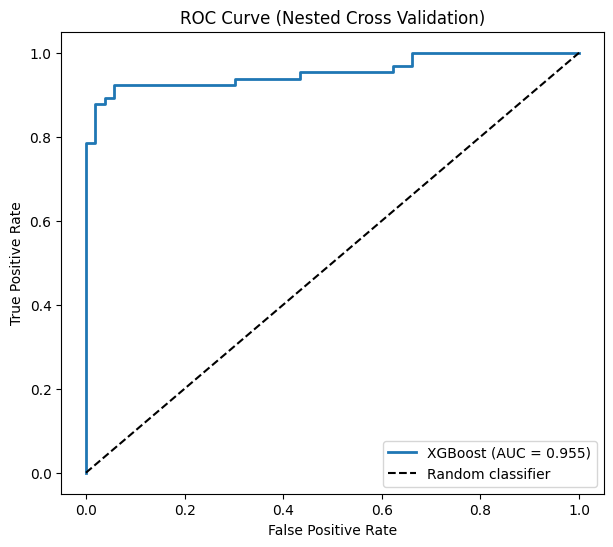

{'roc_auc': [np.float64(1.0),
  np.float64(0.972027972027972),
  np.float64(0.965034965034965),
  np.float64(0.876923076923077),
  np.float64(0.9384615384615385)],
 'accuracy': [1.0,
  0.875,
  0.9583333333333334,
  0.8695652173913043,
  0.9130434782608695],
 'sensitivity': [np.float64(1.0),
  np.float64(0.8461538461538461),
  np.float64(0.9230769230769231),
  np.float64(0.8461538461538461),
  np.float64(0.8461538461538461)],
 'specificity': [np.float64(1.0),
  np.float64(0.9090909090909091),
  np.float64(1.0),
  np.float64(0.9),
  np.float64(1.0)],
 'best_params': [{'subsample': 0.8,
   'reg_lambda': 2,
   'n_estimators': 50,
   'max_depth': 5,
   'learning_rate': 0.1,
   'gamma': 0.0,
   'colsample_bytree': 0.8},
  {'subsample': 0.8,
   'reg_lambda': 1,
   'n_estimators': 100,
   'max_depth': 3,
   'learning_rate': 0.05,
   'gamma': 0.0,
   'colsample_bytree': 0.8},
  {'subsample': 0.7,
   'reg_lambda': 1.5,
   'n_estimators': 75,
   'max_depth': 3,
   'learning_rate': 0.1,
   'gamma

In [ ]:
# with smote
nested_stratified_kfold_cv(X=X, y=y, n_outer_splits=5, n_inner_splits=3, random_state=42, use_smote=True)


Nested CV: 5 outer folds x 3 inner folds

────────────────────────────────────────────────────────────
OUTER Fold 1/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.9524
  Best params           : {'subsample': 0.9, 'reg_lambda': 2, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
  Inner CV Time         : 2.65 seconds
  Outer Accuracy    : 1.0000
  Outer ROC-AUC     : 1.0000
  Outer Sensitivity : 1.0000
  Outer Specificity : 1.0000
  Fold Total Time   : 2.66 seconds

────────────────────────────────────────────────────────────
OUTER Fold 2/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.9919
  Best params           : {'subsample': 0.9, 'reg_lambda': 1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.7}
  Inner CV Time         : 2.62 seconds
  Outer Accuracy    : 0.9167
  Outer ROC-AUC     : 0.9720
  Outer Se

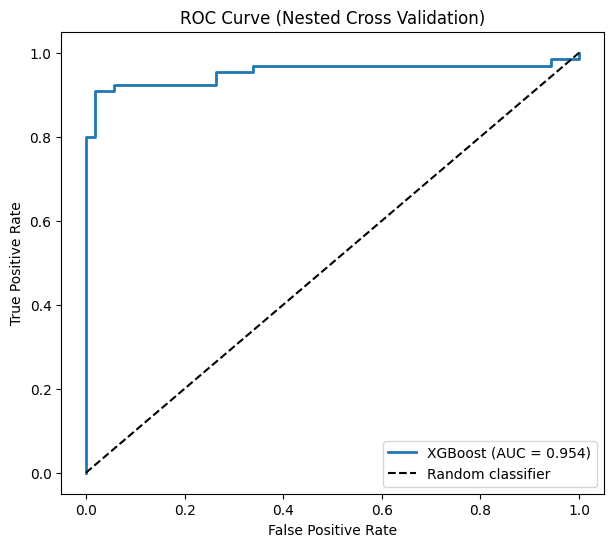

{'roc_auc': [np.float64(1.0),
  np.float64(0.972027972027972),
  np.float64(0.965034965034965),
  np.float64(0.8615384615384616),
  np.float64(0.9692307692307693)],
 'accuracy': [1.0,
  0.9166666666666666,
  0.9583333333333334,
  0.9130434782608695,
  0.8695652173913043],
 'sensitivity': [np.float64(1.0),
  np.float64(0.9230769230769231),
  np.float64(0.9230769230769231),
  np.float64(0.8461538461538461),
  np.float64(0.8461538461538461)],
 'specificity': [np.float64(1.0),
  np.float64(0.9090909090909091),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9)],
 'best_params': [{'subsample': 0.9,
   'reg_lambda': 2,
   'n_estimators': 50,
   'max_depth': 5,
   'learning_rate': 0.1,
   'gamma': 0.1,
   'colsample_bytree': 0.8},
  {'subsample': 0.9,
   'reg_lambda': 1,
   'n_estimators': 100,
   'max_depth': 5,
   'learning_rate': 0.05,
   'gamma': 0.0,
   'colsample_bytree': 0.7},
  {'subsample': 0.7,
   'reg_lambda': 2,
   'n_estimators': 100,
   'max_depth': 4,
   'learning_rate': 0

In [ ]:
#without smote
nested_stratified_kfold_cv(X=X, y=y, n_outer_splits=5, n_inner_splits=3, random_state=42, use_smote=False)

DEMOGRAPHICS ONLY

In [ ]:
#For demographics only
X1 = df[['Age','Sex','Smoking']]

Nested CV: 5 outer folds x 3 inner folds

────────────────────────────────────────────────────────────
OUTER Fold 1/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.7476
  Best params           : {'subsample': 0.7, 'reg_lambda': 2, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.7}
  Inner CV Time         : 1.99 seconds
  Outer Accuracy    : 0.7917
  Outer ROC-AUC     : 0.8322
  Outer Sensitivity : 0.7692
  Outer Specificity : 0.8182
  Fold Total Time   : 2.01 seconds

────────────────────────────────────────────────────────────
OUTER Fold 2/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.7809
  Best params           : {'subsample': 0.7, 'reg_lambda': 1, 'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
  Inner CV Time         : 1.94 seconds
  Outer Accuracy    : 0.7500
  Outer ROC-AUC     : 0.8217
  Outer S

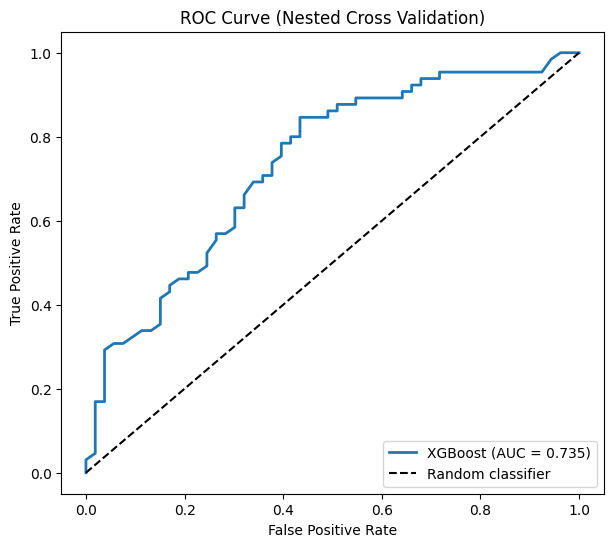

{'roc_auc': [np.float64(0.8321678321678322),
  np.float64(0.8216783216783218),
  np.float64(0.7657342657342658),
  np.float64(0.6730769230769231),
  np.float64(0.7307692307692308)],
 'accuracy': [0.7916666666666666,
  0.75,
  0.6666666666666666,
  0.5652173913043478,
  0.6521739130434783],
 'sensitivity': [np.float64(0.7692307692307693),
  np.float64(0.9230769230769231),
  np.float64(0.9230769230769231),
  np.float64(0.6153846153846154),
  np.float64(0.46153846153846156)],
 'specificity': [np.float64(0.8181818181818182),
  np.float64(0.5454545454545454),
  np.float64(0.36363636363636365),
  np.float64(0.5),
  np.float64(0.9)],
 'best_params': [{'subsample': 0.7,
   'reg_lambda': 2,
   'n_estimators': 100,
   'max_depth': 4,
   'learning_rate': 0.05,
   'gamma': 0.0,
   'colsample_bytree': 0.7},
  {'subsample': 0.7,
   'reg_lambda': 1,
   'n_estimators': 100,
   'max_depth': 2,
   'learning_rate': 0.1,
   'gamma': 0.1,
   'colsample_bytree': 0.7},
  {'subsample': 0.7,
   'reg_lambda': 2

In [ ]:
#with smote
nested_stratified_kfold_cv(X=X1, y=y, n_outer_splits=5, n_inner_splits=3, random_state=42, use_smote=True)

Nested CV: 5 outer folds x 3 inner folds

────────────────────────────────────────────────────────────
OUTER Fold 1/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.7363
  Best params           : {'subsample': 0.7, 'reg_lambda': 2, 'n_estimators': 75, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.8}
  Inner CV Time         : 1.95 seconds
  Outer Accuracy    : 0.7917
  Outer ROC-AUC     : 0.8322
  Outer Sensitivity : 0.9231
  Outer Specificity : 0.6364
  Fold Total Time   : 1.96 seconds

────────────────────────────────────────────────────────────
OUTER Fold 2/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.7132
  Best params           : {'subsample': 0.9, 'reg_lambda': 1, 'n_estimators': 75, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.7}
  Inner CV Time         : 1.92 seconds
  Outer Accuracy    : 0.7500
  Outer ROC-AUC     : 0.8427
  Outer Se

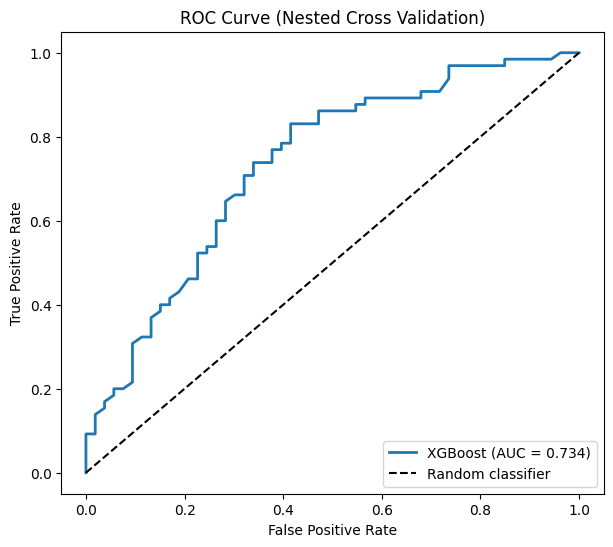

{'roc_auc': [np.float64(0.8321678321678322),
  np.float64(0.8426573426573427),
  np.float64(0.7727272727272727),
  np.float64(0.6576923076923078),
  np.float64(0.7730769230769231)],
 'accuracy': [0.7916666666666666,
  0.75,
  0.6666666666666666,
  0.5652173913043478,
  0.6956521739130435],
 'sensitivity': [np.float64(0.9230769230769231),
  np.float64(0.7692307692307693),
  np.float64(0.9230769230769231),
  np.float64(0.6153846153846154),
  np.float64(0.6153846153846154)],
 'specificity': [np.float64(0.6363636363636364),
  np.float64(0.7272727272727273),
  np.float64(0.36363636363636365),
  np.float64(0.5),
  np.float64(0.8)],
 'best_params': [{'subsample': 0.7,
   'reg_lambda': 2,
   'n_estimators': 75,
   'max_depth': 2,
   'learning_rate': 0.05,
   'gamma': 0.0,
   'colsample_bytree': 0.8},
  {'subsample': 0.9,
   'reg_lambda': 1,
   'n_estimators': 75,
   'max_depth': 4,
   'learning_rate': 0.05,
   'gamma': 0.0,
   'colsample_bytree': 0.7},
  {'subsample': 0.9,
   'reg_lambda': 1.5

In [ ]:
#without smote
nested_stratified_kfold_cv(X=X1, y=y, n_outer_splits=5, n_inner_splits=3, random_state=42, use_smote=False)

SENSORS + DEMOGRAPHICS

In [ ]:
#For sensor+ demographics
X2 = df.drop(columns=["Group","LC_stage","LC_type","lscm","Group_name"])
display(X2.head())

,S1_T1,S2_T1,S3_T1,S4_T1,S5_T1,S6_T1,S1_T2,S2_T2,S3_T2,S4_T2,...,S6_T2,S1_T3,S2_T3,S3_T3,S4_T3,S5_T3,S6_T3,Age,Sex,Smoking
0,3.180000e-07,3.730000e-07,0.000230,9.420000e-07,5.440000e-07,7.010000e-07,6.790000e-07,6.920000e-07,0.000202,0.000004,...,1.500000e-06,5.560000e-07,2.720000e-07,0.000035,0.000004,8.850000e-07,7.660000e-07,50,1,1
1,3.300000e-07,2.770000e-07,0.000268,1.120000e-06,8.950000e-07,1.050000e-06,2.660000e-07,1.890000e-07,0.000095,0.000002,...,8.760000e-07,2.110000e-07,1.750000e-07,0.000035,0.000004,1.160000e-06,9.310000e-07,68,0,0
2,5.450000e-07,4.810000e-07,0.000527,2.400000e-06,2.260000e-06,2.310000e-06,7.360000e-07,5.290000e-07,0.000266,0.000005,...,2.750000e-06,6.980000e-07,5.250000e-07,0.000119,0.000013,4.080000e-06,3.070000e-06,70,1,1
3,3.780000e-07,4.190000e-07,0.000241,1.100000e-06,9.490000e-07,1.010000e-06,3.580000e-07,3.750000e-07,0.000095,0.000002,...,9.480000e-07,2.760000e-07,3.300000e-07,0.000038,0.000005,1.420000e-06,1.070000e-06,66,0,0
4,4.260000e-07,4.780000e-07,0.000276,1.440000e-06,8.630000e-07,1.050000e-06,4.350000e-07,4.680000e-07,0.000120,0.000003,...,1.170000e-06,3.210000e-07,3.700000e-07,0.000044,0.000006,1.400000e-06,1.190000e-06,69,1,1


Nested CV: 5 outer folds x 3 inner folds

────────────────────────────────────────────────────────────
OUTER Fold 1/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.9393
  Best params           : {'subsample': 0.9, 'reg_lambda': 2, 'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.9}
  Inner CV Time         : 2.83 seconds
  Outer Accuracy    : 0.9583
  Outer ROC-AUC     : 1.0000
  Outer Sensitivity : 0.9231
  Outer Specificity : 1.0000
  Fold Total Time   : 2.84 seconds

────────────────────────────────────────────────────────────
OUTER Fold 2/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.9821
  Best params           : {'subsample': 0.9, 'reg_lambda': 1.5, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.9}
  Inner CV Time         : 2.82 seconds
  Outer Accuracy    : 0.9167
  Outer ROC-AUC     : 0.9720
  Oute

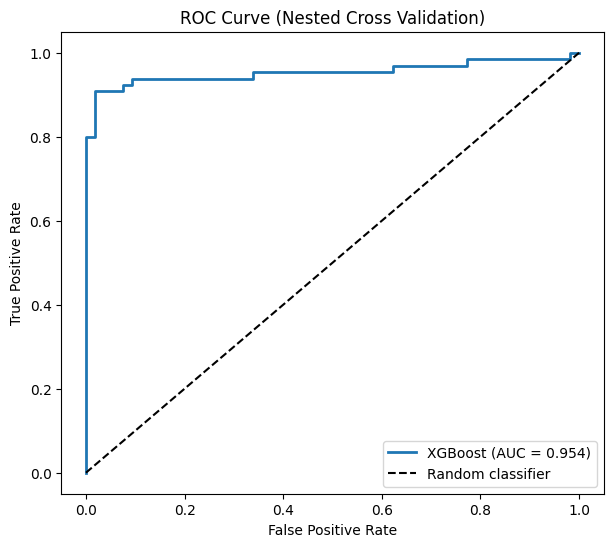

{'roc_auc': [np.float64(1.0),
  np.float64(0.972027972027972),
  np.float64(0.993006993006993),
  np.float64(0.876923076923077),
  np.float64(0.9615384615384615)],
 'accuracy': [0.9583333333333334,
  0.9166666666666666,
  0.9583333333333334,
  0.9130434782608695,
  0.9130434782608695],
 'sensitivity': [np.float64(0.9230769230769231),
  np.float64(0.9230769230769231),
  np.float64(0.9230769230769231),
  np.float64(0.8461538461538461),
  np.float64(0.8461538461538461)],
 'specificity': [np.float64(1.0),
  np.float64(0.9090909090909091),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0)],
 'best_params': [{'subsample': 0.9,
   'reg_lambda': 2,
   'n_estimators': 100,
   'max_depth': 2,
   'learning_rate': 0.05,
   'gamma': 0.0,
   'colsample_bytree': 0.9},
  {'subsample': 0.9,
   'reg_lambda': 1.5,
   'n_estimators': 100,
   'max_depth': 3,
   'learning_rate': 0.05,
   'gamma': 0.0,
   'colsample_bytree': 0.9},
  {'subsample': 0.7,
   'reg_lambda': 2,
   'n_estimators': 100,
   'max

In [ ]:
#with smote
nested_stratified_kfold_cv(X=X2, y=y, n_outer_splits=5, n_inner_splits=3, random_state=42, use_smote=True)

Nested CV: 5 outer folds x 3 inner folds

────────────────────────────────────────────────────────────
OUTER Fold 1/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.9538
  Best params           : {'subsample': 0.9, 'reg_lambda': 1.5, 'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.0, 'colsample_bytree': 0.9}
  Inner CV Time         : 2.74 seconds
  Outer Accuracy    : 1.0000
  Outer ROC-AUC     : 1.0000
  Outer Sensitivity : 1.0000
  Outer Specificity : 1.0000
  Fold Total Time   : 2.76 seconds

────────────────────────────────────────────────────────────
OUTER Fold 2/5
────────────────────────────────────────────────────────────
  Best inner CV ROC-AUC : 0.9920
  Best params           : {'subsample': 0.9, 'reg_lambda': 2, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
  Inner CV Time         : 2.63 seconds
  Outer Accuracy    : 0.9167
  Outer ROC-AUC     : 0.9720
  Outer Se

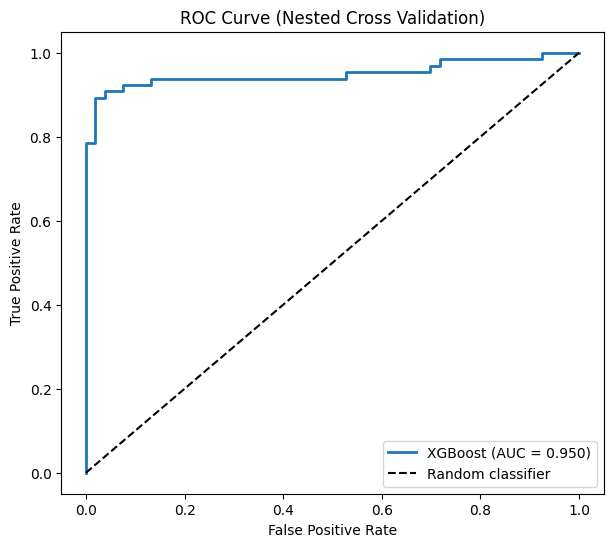

{'roc_auc': [np.float64(1.0),
  np.float64(0.972027972027972),
  np.float64(1.0),
  np.float64(0.8615384615384616),
  np.float64(0.9307692307692307)],
 'accuracy': [1.0,
  0.9166666666666666,
  0.9583333333333334,
  0.8695652173913043,
  0.8695652173913043],
 'sensitivity': [np.float64(1.0),
  np.float64(0.9230769230769231),
  np.float64(0.9230769230769231),
  np.float64(0.8461538461538461),
  np.float64(0.7692307692307693)],
 'specificity': [np.float64(1.0),
  np.float64(0.9090909090909091),
  np.float64(1.0),
  np.float64(0.9),
  np.float64(1.0)],
 'best_params': [{'subsample': 0.9,
   'reg_lambda': 1.5,
   'n_estimators': 50,
   'max_depth': 4,
   'learning_rate': 0.1,
   'gamma': 0.0,
   'colsample_bytree': 0.9},
  {'subsample': 0.9,
   'reg_lambda': 2,
   'n_estimators': 50,
   'max_depth': 5,
   'learning_rate': 0.1,
   'gamma': 0.1,
   'colsample_bytree': 0.8},
  {'subsample': 0.9,
   'reg_lambda': 1,
   'n_estimators': 100,
   'max_depth': 5,
   'learning_rate': 0.1,
   'gamma'

In [ ]:
#without smote
nested_stratified_kfold_cv(X=X2, y=y, n_outer_splits=5, n_inner_splits=3, random_state=42, use_smote=False)

Running Model 1: Sensors only (with SMOTE) …
  [Sensors only] Fold 1: AUC = 1.0000
  [Sensors only] Fold 2: AUC = 0.9720
  [Sensors only] Fold 3: AUC = 0.9650
  [Sensors only] Fold 4: AUC = 0.8769
  [Sensors only] Fold 5: AUC = 0.9385

  [Sensors only] Mean AUC = 0.9505 ± 0.0417

Running Model 2: Demographics only (with SMOTE) …
  [Demographics only] Fold 1: AUC = 0.8322
  [Demographics only] Fold 2: AUC = 0.8217
  [Demographics only] Fold 3: AUC = 0.7657
  [Demographics only] Fold 4: AUC = 0.6731
  [Demographics only] Fold 5: AUC = 0.7308

  [Demographics only] Mean AUC = 0.7647 ± 0.0589

Running Model 3: Sensors + Demographics (with SMOTE) …
  [Sensors + Demographics] Fold 1: AUC = 1.0000
  [Sensors + Demographics] Fold 2: AUC = 0.9720
  [Sensors + Demographics] Fold 3: AUC = 0.9930
  [Sensors + Demographics] Fold 4: AUC = 0.8769
  [Sensors + Demographics] Fold 5: AUC = 0.9615

  [Sensors + Demographics] Mean AUC = 0.9607 ± 0.0441



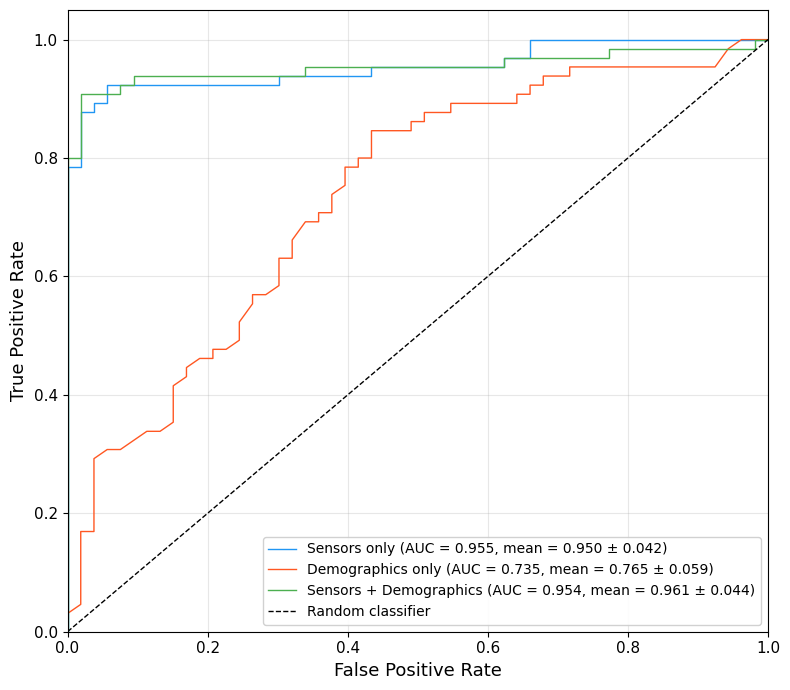

Saved → Combined_ROC_all_models.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# Combined ROC Curve Plot – All Three XGBoost Models (with SMOTE)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import time

#run nested CV and return (fpr, tpr, auc, outer_results) ──────────
def nested_cv_roc(X, y, n_outer_splits=5, n_inner_splits=3,
                  random_state=42, use_smote=False, label="Model"):
    """
    Same nested CV logic as the original function but returns ROC curve data
    (fpr, tpr, roc_auc_value) alongside outer_results for the combined plot.
    """
    outer_skf = StratifiedKFold(n_splits=n_outer_splits, shuffle=True,
                                random_state=random_state)
    inner_skf = StratifiedKFold(n_splits=n_inner_splits, shuffle=True,
                                random_state=random_state)

    param_distributions = {
        'n_estimators':     [50, 75, 100],
        'max_depth':        [2, 3, 4, 5],
        'learning_rate':    [0.05, 0.1],
        'gamma':            [0.0, 0.1],
        'subsample':        [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'reg_lambda':       [1, 1.5, 2],
    }

    outer_results = {
        'roc_auc': [], 'accuracy': [],
        'sensitivity': [], 'specificity': [],
        'best_params': [], 'inner_search_time': [], 'fold_total_time': []
    }

    all_y_test, all_y_prob = [], []
    X_values = X.values if hasattr(X, 'values') else X
    y_values = y.values if hasattr(y, 'values') else y

    for outer_fold, (train_idx, test_idx) in enumerate(
            outer_skf.split(X_values, y_values), 1):

        outer_start = time.time()
        X_tr, X_te = X_values[train_idx], X_values[test_idx]
        y_tr, y_te = y_values[train_idx], y_values[test_idx]

        scaler = RobustScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        if use_smote:
            smote = SMOTE(random_state=random_state)
            X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

        base_model = XGBClassifier(random_state=random_state,
                                   eval_metric='logloss')
        rs = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_distributions,
            n_iter=50, cv=inner_skf, scoring='roc_auc',
            n_jobs=-1, random_state=random_state, verbose=0, refit=True
        )
        inner_start = time.time()
        rs.fit(X_tr, y_tr)
        inner_time = time.time() - inner_start

        best_model = rs.best_estimator_
        y_pred       = best_model.predict(X_te)
        y_pred_proba = best_model.predict_proba(X_te)[:, 1]

        all_y_test.extend(y_te)
        all_y_prob.extend(y_pred_proba)

        cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        outer_results['roc_auc'].append(roc_auc_score(y_te, y_pred_proba))
        outer_results['accuracy'].append(accuracy_score(y_te, y_pred))
        outer_results['sensitivity'].append(tp / (tp + fn))
        outer_results['specificity'].append(tn / (tn + fp))
        outer_results['best_params'].append(rs.best_params_)
        outer_results['inner_search_time'].append(inner_time)
        outer_results['fold_total_time'].append(time.time() - outer_start)

        print(f"  [{label}] Fold {outer_fold}: AUC = {outer_results['roc_auc'][-1]:.4f}")

    fpr, tpr, _ = roc_curve(all_y_test, all_y_prob)
    roc_auc_value = auc(fpr, tpr)
    mean_auc = np.mean(outer_results['roc_auc'])
    std_auc  = np.std(outer_results['roc_auc'])

    print(f"\n  [{label}] Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}\n")
    return fpr, tpr, roc_auc_value, mean_auc, std_auc, outer_results


# ── Run all three models ──────────────────────────────────────────────────────
print("Running Model 1: Sensors only (with SMOTE) …")
fpr1, tpr1, auc1, mean1, std1, res1 = nested_cv_roc(
    X=X, y=y, use_smote=True, label="Sensors only")

print("Running Model 2: Demographics only (with SMOTE) …")
fpr2, tpr2, auc2, mean2, std2, res2 = nested_cv_roc(
    X=X1, y=y, use_smote=True, label="Demographics only")

print("Running Model 3: Sensors + Demographics (with SMOTE) …")
fpr3, tpr3, auc3, mean3, std3, res3 = nested_cv_roc(
    X=X2, y=y, use_smote=True, label="Sensors + Demographics")


# ── Combined ROC plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

colors  = ['#2196F3', '#FF5722', '#4CAF50']
styles  = ['-',       '-',      '-']
labels  = [
    f'Sensors only (AUC = {auc1:.3f}, mean = {mean1:.3f} ± {std1:.3f})',
    f'Demographics only (AUC = {auc2:.3f}, mean = {mean2:.3f} ± {std2:.3f})',
    f'Sensors + Demographics (AUC = {auc3:.3f}, mean = {mean3:.3f} ± {std3:.3f})',
]

for fpr, tpr, color, ls, lbl in zip(
        [fpr1, fpr2, fpr3],
        [tpr1, tpr2, tpr3],
        colors, styles, labels):
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=1.0, label=lbl)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',       fontsize=13)
#ax.set_title('Combined ROC Curves – Nested Cross-Validation\n(XGBoost, with SMOTE)',
             #fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('Combined_ROC_all_models.tiff', dpi=600, bbox_inches='tight')
plt.show()
print("Saved → Combined_ROC_all_models.png")
from google.colab import files
files.download("Combined_ROC_all_models.tiff")